In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [3]:
df = pd.read_csv('/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/credit_risk_assessment_500_samples.csv')
df.head()

,Applicant_ID,Age,Annual_Income,Employment_Years,Credit_Score,Loan_Amount,Loan_Term_Months,Existing_Loans_Count,Debt_to_Income_Ratio,Late_Payments_Last_2Yrs,Credit_Risk
0,1,59,153267,28,818,196649,12,2,0.68,0,High
1,2,49,232745,0,436,175354,60,0,0.23,5,High
2,3,35,974945,19,797,662297,48,3,0.54,0,Medium
3,4,63,307164,29,776,831725,48,0,0.56,4,High
4,5,28,685626,6,893,498625,60,3,0.66,8,High


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Applicant_ID             500 non-null    int64  
 1   Age                      500 non-null    int64  
 2   Annual_Income            500 non-null    int64  
 3   Employment_Years         500 non-null    int64  
 4   Credit_Score             500 non-null    int64  
 5   Loan_Amount              500 non-null    int64  
 6   Loan_Term_Months         500 non-null    int64  
 7   Existing_Loans_Count     500 non-null    int64  
 8   Debt_to_Income_Ratio     500 non-null    float64
 9   Late_Payments_Last_2Yrs  500 non-null    int64  
 10  Credit_Risk              500 non-null    object 
dtypes: float64(1), int64(9), object(1)
memory usage: 43.1+ KB


In [5]:
print(df['Credit_Risk'].value_counts())

Credit_Risk
High      315
Medium    164
Low        21
Name: count, dtype: int64


In [6]:
X = df.drop(['Applicant_ID', 'Credit_Risk'], axis=1)
y = df['Credit_Risk']

In [7]:
le = LabelEncoder()
y = le.fit_transform(y)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [11]:
RF = RandomForestClassifier(random_state=42)
RF.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [12]:
GB = GradientBoostingClassifier(random_state=42)
GB.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [13]:
LR_acc = accuracy_score(y_test, LR.predict(X_test_scaled))
RF_acc = accuracy_score(y_test, RF.predict(X_test))
GB_acc = accuracy_score(y_test, GB.predict(X_test))

In [14]:
print(f"Logistic Regression Accuracy: {LR_acc:.4f}")
print(f"Random Forest Accuracy: {RF_acc:.4f}")
print(f"Gradient Boosting Accuracy: {GB_acc:.4f}")

Logistic Regression Accuracy: 0.8500
Random Forest Accuracy: 0.9800
Gradient Boosting Accuracy: 1.0000


In [15]:
LR_p = precision_score(y_test, LR.predict(X_test_scaled), average='macro')
RF_p = precision_score(y_test, RF.predict(X_test), average='macro')
GB_p = precision_score(y_test, GB.predict(X_test), average='macro')

LR_r = recall_score(y_test, LR.predict(X_test_scaled), average='macro')
RF_r = recall_score(y_test, RF.predict(X_test), average='macro')
GB_r = recall_score(y_test, GB.predict(X_test), average='macro')

LR_f1 = f1_score(y_test, LR.predict(X_test_scaled), average='macro')
RF_f1 = f1_score(y_test, RF.predict(X_test), average='macro')
GB_f1 = f1_score(y_test, GB.predict(X_test), average='macro')

In [16]:


print("\n--- Detailed Metrics (Precision, Recall, F1) ---")
print(f"Logistic Regression -> Precision: {LR_p:.2f}, Recall: {LR_r:.2f}, F1: {LR_f1:.2f}")
print(f"Random Forest -> Precision: {RF_p:.2f}, Recall: {RF_r:.2f}, F1: {RF_f1:.2f}")
print(f"Gradient Boosting -> Precision: {GB_p:.2f}, Recall: {GB_r:.2f}, F1: {GB_f1:.2f}")


--- Detailed Metrics (Precision, Recall, F1) ---
Logistic Regression -> Precision: 0.81, Recall: 0.76, F1: 0.79
Random Forest -> Precision: 0.98, Recall: 0.87, F1: 0.91
Gradient Boosting -> Precision: 1.00, Recall: 1.00, F1: 1.00


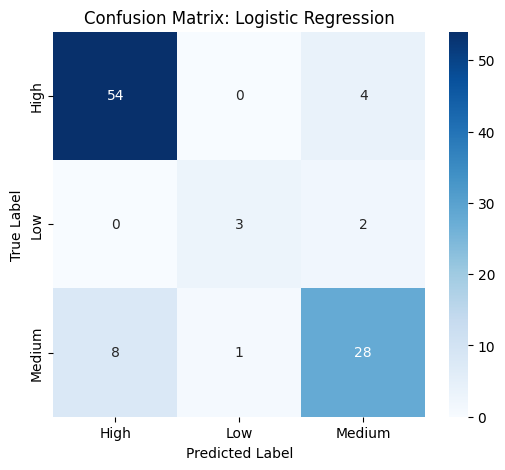

In [17]:
lr_cm = confusion_matrix(y_test, LR.predict(X_test_scaled))

plt.figure(figsize=(6, 5))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

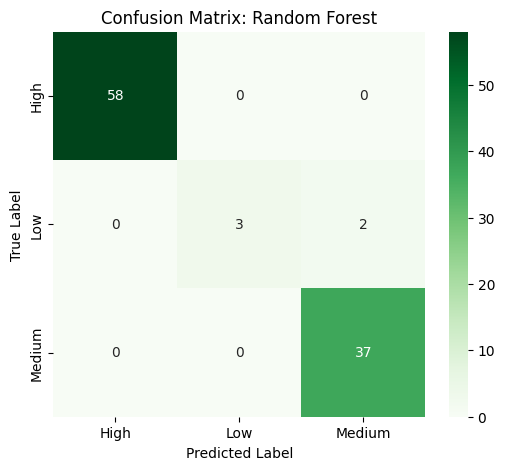

In [18]:
rf_cm = confusion_matrix(y_test, RF.predict(X_test))

plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

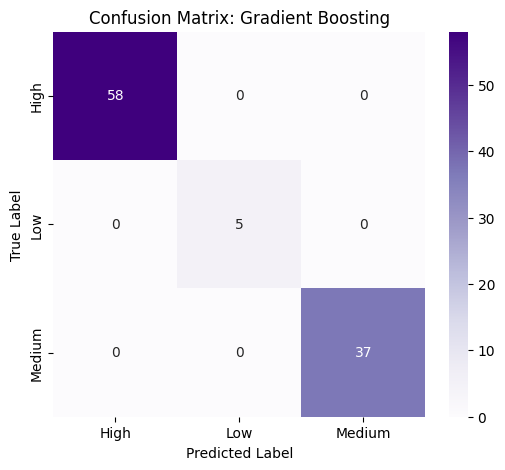

In [19]:
gb_cm = confusion_matrix(y_test, GB.predict(X_test))

plt.figure(figsize=(6, 5))
sns.heatmap(gb_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Gradient Boosting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
import pickle


with open('/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/exp6_models/lr_model.pkl', 'wb') as f:
    pickle.dump(LR, f)

with open('/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/exp6_models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/exp6_models/rf_model.pkl', 'wb') as f:
    pickle.dump(RF, f)


with open('/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/exp6_models/gb_model.pkl', 'wb') as f:
    pickle.dump(GB, f)


with open('/content/drive/MyDrive/AIML_lab_sem4/exp 5,6,7/exp6_models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)



### Model Performance Comparison

/tmp/ipykernel_2611/3605947226.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette=[colors[i]])
/tmp/ipykernel_2611/3605947226.py:18: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette=[colors[i]])
/tmp/ipykernel_2611/3605947226.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette=[colors[i]])
/tmp/ipykernel_2611/3605947226.py:18: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produc

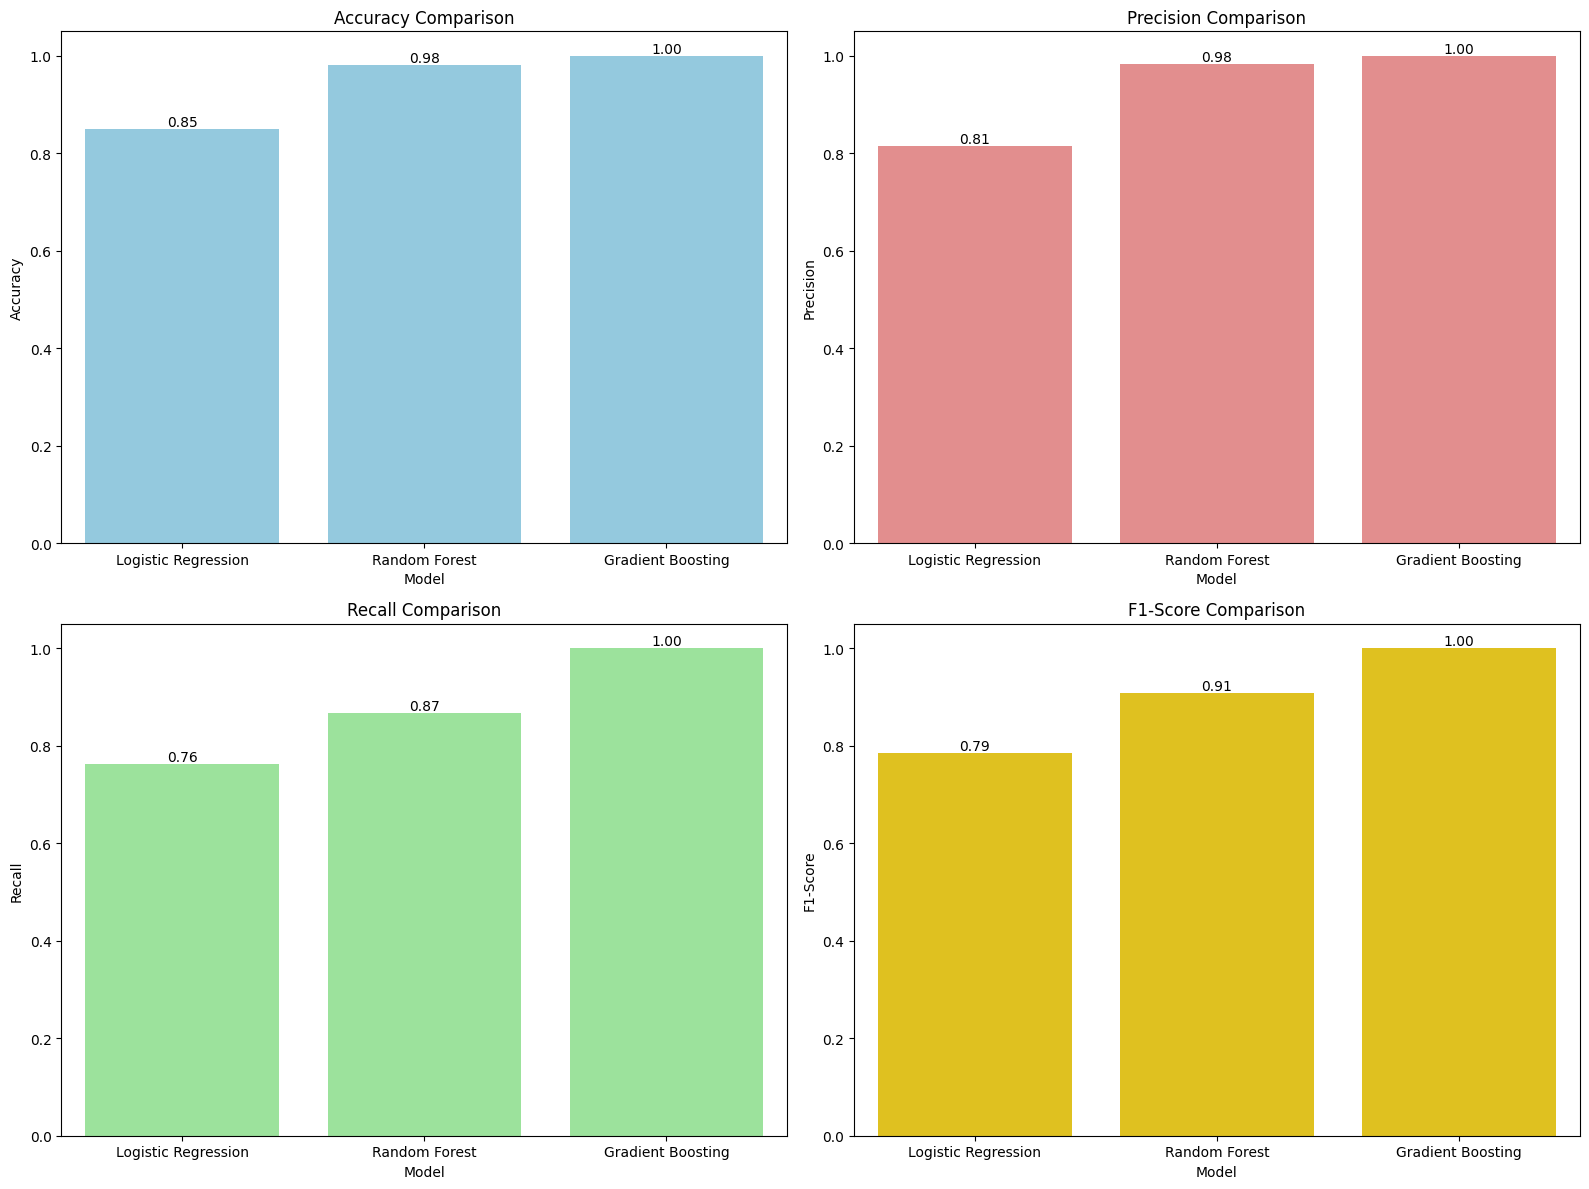

In [20]:
metrics_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [LR_acc, RF_acc, GB_acc],
    'Precision': [LR_p, RF_p, GB_p],
    'Recall': [LR_r, RF_r, GB_r],
    'F1-Score': [LR_f1, RF_f1, GB_f1]
}

metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette=[colors[i]])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylim(0, 1.05)
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()